# Assignment No. 2

Name: yash vyas<br>
Roll No.: IT-2K24-97

## Question 1: Finding Roots of Polynomial Equations

In [1]:
def f(x):
    return x**3 - 2 * x - 5


def df(x):
    return 3 * x**2 - 2


def g(x):
    return (2 * x + 5) ** (1 / 3)

### Method 1: Bisection Method

**Assumptions**

- f(x) is continuous on [a, b].
- f(a) * f(b) < 0 (root is bracketed).
- Tolerance e > 0 and max iterations N are given.

**Algorithm (Bisection Method)**

1. Start
2. Read function f(x), interval a, b, tolerance e, max iterations N
3. Compute f(a), f(b)
4. If f(a) * f(b) >= 0, print "Invalid interval"
5. Stop
6. Repeat for i = 1 to N
7.    m = (a + b) / 2
8.    Compute f(m)
9.    If |f(m)| <= e or (b - a) / 2 <= e, print m as root
10.   Stop
11.   If f(a) * f(m) < 0, set b = m
12.   Else set a = m
13. End Repeat
14. Print m as approximate root
15. Stop
16. End

,ITERATION NO.,A,B,M=(A+B)/2,F(M),F(M)*F(A),ERROR,H
0,1,2.000000,3.000000,2.500000,5.625000,-5.625000e+00,5.625000,0.500000
1,2,2.000000,2.500000,2.250000,1.890625,-1.890625e+00,1.890625,0.250000
2,3,2.000000,2.250000,2.125000,0.345703,-3.457031e-01,0.345703,0.125000
3,4,2.000000,2.125000,2.062500,-0.351318,3.513184e-01,0.351318,0.062500
4,5,2.062500,2.125000,2.093750,-0.008942,3.141366e-03,0.008942,0.031250
5,6,2.093750,2.125000,2.109375,0.166836,-1.491787e-03,0.166836,0.015625
6,7,2.093750,2.109375,2.101562,0.078562,-7.024763e-04,0.078562,0.007812
7,8,2.093750,2.101562,2.097656,0.034714,-3.104030e-04,0.034714,0.003906
8,9,2.093750,2.097656,2.095703,0.012862,-1.150105e-04,0.012862,0.001953
9,10,2.093750,2.095703,2.094727,0.001954,-1.747510e-05,0.001954,0.000977


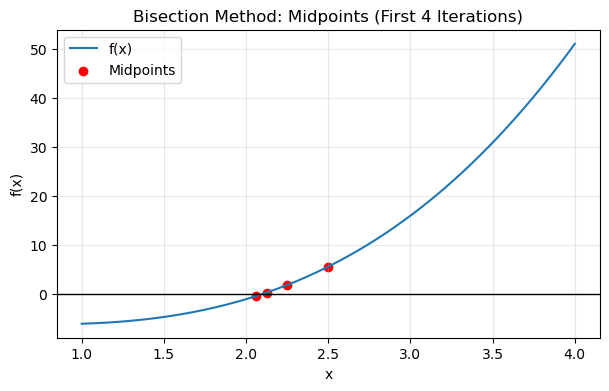

Bisection Root: 2.09454345703125
Iterations: 14


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def bisection_method(func, a, b, tol=1e-4, max_iter=100):
    fa = func(a)
    fb = func(b)
    rows = []

    if fa * fb >= 0:
        raise ValueError("Bisection method requires f(a) * f(b) < 0.")

    for iteration in range(1, max_iter + 1):
        c = (a + b) / 2.0
        fc = func(c)
        h = (b - a) / 2.0
        rows.append({
            "ITERATION NO.": iteration,
            "A": a,
            "B": b,
            "M=(A+B)/2": c,
            "F(M)": fc,
            "F(M)*F(A)": fc * fa,
            "ERROR": abs(fc),
            "H": h,
        })

        if abs(fc) <= tol or h <= tol:
            return c, iteration, pd.DataFrame(rows)

        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc

    return c, max_iter, pd.DataFrame(rows)


root, iterations, table = bisection_method(f, 2.0, 3.0, tol=1e-4)
display(table)

xs = np.linspace(1.0, 4.0, 400)
ys = [f(x) for x in xs]
midpoints = table["M=(A+B)/2"].head(4)
mid_vals = [f(x) for x in midpoints]

plt.figure(figsize=(7, 4))
plt.plot(xs, ys, label="f(x)")
plt.axhline(0, color="black", linewidth=1)
plt.scatter(midpoints, mid_vals, color="red", label="Midpoints")
plt.title("Bisection Method: Midpoints (First 4 Iterations)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Bisection Root:", root)
print("Iterations:", iterations)

Time Complexity: O(log2((b-a)/tol))

Space Complexity: O(1)

### Method 2: Regula-Falsi Method

**Assumptions**

- f(x) is continuous on [a, b].
- f(a) * f(b) < 0 (root is bracketed).
- Tolerance e > 0 and max iterations N are given.

**Algorithm (Regula-Falsi Method)**

1. Start
2. Read function f(x), interval a, b, tolerance e, max iterations N
3. Compute f(a), f(b)
4. If f(a) * f(b) >= 0, print "Invalid interval"
5. Stop
6. Repeat for i = 1 to N
7.    x = (a * f(b) - b * f(a)) / (f(b) - f(a))
8.    Compute f(x)
9.    If |f(x)| <= e, print x as root
10.   Stop
11.   If f(a) * f(x) < 0, set b = x
12.   Else set a = x
13. End Repeat
14. Print x as approximate root
15. Stop
16. End

,ITERATION NO.,A,B,X,F(X),F(X)*F(A),ERROR
0,1,2.000000,3.0,2.058824,-0.390800,3.907999e-01,0.390800
1,2,2.058824,3.0,2.081264,-0.147204,5.752733e-02,0.147204
2,3,2.081264,3.0,2.089639,-0.054677,8.048603e-03,0.054677
3,4,2.089639,3.0,2.092740,-0.020203,1.104622e-03,0.020203
4,5,2.092740,3.0,2.093884,-0.007451,1.505216e-04,0.007451
5,6,2.093884,3.0,2.094305,-0.002746,2.045665e-05,0.002746
6,7,2.094305,3.0,2.094461,-0.001012,2.777451e-06,0.001012
7,8,2.094461,3.0,2.094518,-0.000373,3.769659e-07,0.000373
8,9,2.094518,3.0,2.094539,-0.000137,5.115642e-08,0.000137
9,10,2.094539,3.0,2.094547,-0.000051,6.941878e-09,0.000051


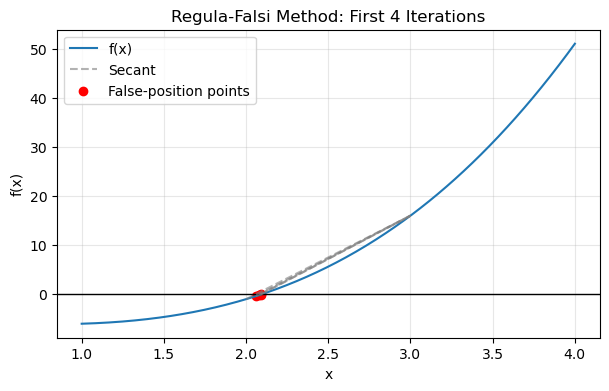

Regula-Falsi Root: 2.094546950874257
Iterations: 10


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def regula_falsi_method(func, a, b, tol=1e-4, max_iter=100):
    fa = func(a)
    fb = func(b)
    rows = []

    if fa * fb >= 0:
        raise ValueError("Regula-Falsi method requires f(a) * f(b) < 0.")

    x = a
    for iteration in range(1, max_iter + 1):
        x = (a * fb - b * fa) / (fb - fa)
        fx = func(x)
        rows.append({
            "ITERATION NO.": iteration,
            "A": a,
            "B": b,
            "X": x,
            "F(X)": fx,
            "F(X)*F(A)": fx * fa,
            "ERROR": abs(fx),
        })

        if abs(fx) <= tol:
            return x, iteration, pd.DataFrame(rows)

        if fa * fx < 0:
            b = x
            fb = fx
        else:
            a = x
            fa = fx

    return x, max_iter, pd.DataFrame(rows)


root, iterations, table = regula_falsi_method(f, 2.0, 3.0, tol=1e-4)
display(table)

xs = np.linspace(1.0, 4.0, 400)
ys = [f(x) for x in xs]
rows = table.head(4)

plt.figure(figsize=(7, 4))
plt.plot(xs, ys, label="f(x)")
plt.axhline(0, color="black", linewidth=1)
for i, row in rows.iterrows():
    a = row["A"]
    b = row["B"]
    label = "Secant" if i == rows.index[0] else "_nolegend_"
    plt.plot([a, b], [f(a), f(b)], "--", color="gray", alpha=0.6, label=label)
plt.scatter(rows["X"], [f(x) for x in rows["X"]], color="red", label="False-position points")
plt.title("Regula-Falsi Method: First 4 Iterations")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Regula-Falsi Root:", root)
print("Iterations:", iterations)

Time Complexity: O(k)

Space Complexity: O(1)

### Method 3: Secant Method

**Assumptions**

- f(x) is continuous near the root.
- Initial guesses x0 and x1 are given with f(x0) != f(x1).
- Tolerance e > 0 and max iterations N are given.

**Algorithm (Secant Method)**

1. Start
2. Read function f(x), initial guesses x0, x1, tolerance e, max iterations N
3. Repeat for i = 1 to N
4.    Compute f(x0), f(x1)
5.    If f(x1) - f(x0) == 0, print "Division by zero"
6.    Stop
7.    x2 = x1 - f(x1) * (x1 - x0) / (f(x1) - f(x0))
8.    If |x2 - x1| <= e or |f(x2)| <= e, print x2 as root
9.    Stop
10.   Set x0 = x1, x1 = x2
11. End Repeat
12. Print x2 as approximate root
13. Stop
14. End

,ITERATION NO.,X0,X1,X2,F(X2),ERROR
0,1,2.000000,3.000000,2.058824,-0.390800,0.941176
1,2,3.000000,2.058824,2.081264,-0.147204,0.022440
2,3,2.058824,2.081264,2.094824,0.003044,0.013560
3,4,2.081264,2.094824,2.094549,-0.000023,0.000275


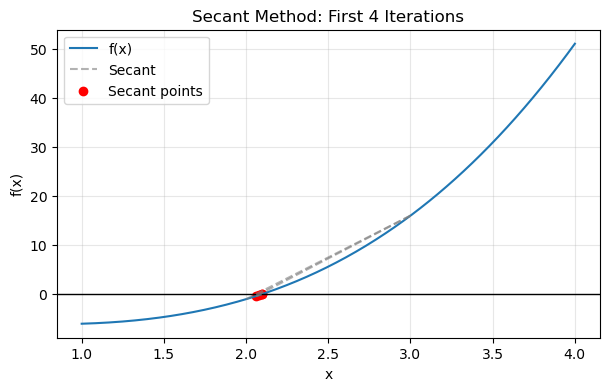

Secant Root: 2.0945494310352473
Iterations: 4


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def secant_method(func, x0, x1, tol=1e-4, max_iter=100):
    f0 = func(x0)
    f1 = func(x1)
    rows = []

    for iteration in range(1, max_iter + 1):
        denominator = f1 - f0
        if denominator == 0:
            raise ZeroDivisionError("Secant method encountered division by zero.")

        x2 = x1 - f1 * (x1 - x0) / denominator
        f2 = func(x2)
        rows.append({
            "ITERATION NO.": iteration,
            "X0": x0,
            "X1": x1,
            "X2": x2,
            "F(X2)": f2,
            "ERROR": abs(x2 - x1),
        })

        if abs(x2 - x1) <= tol or abs(f2) <= tol:
            return x2, iteration, pd.DataFrame(rows)

        x0, f0 = x1, f1
        x1, f1 = x2, f2

    return x2, max_iter, pd.DataFrame(rows)


root, iterations, table = secant_method(f, 2.0, 3.0, tol=1e-4)
display(table)

xs = np.linspace(1.0, 4.0, 400)
ys = [f(x) for x in xs]
rows = table.head(4)

plt.figure(figsize=(7, 4))
plt.plot(xs, ys, label="f(x)")
plt.axhline(0, color="black", linewidth=1)
for i, row in rows.iterrows():
    x0 = row["X0"]
    x1 = row["X1"]
    label = "Secant" if i == rows.index[0] else "_nolegend_"
    plt.plot([x0, x1], [f(x0), f(x1)], "--", color="gray", alpha=0.6, label=label)
plt.scatter(rows["X2"], [f(x) for x in rows["X2"]], color="red", label="Secant points")
plt.title("Secant Method: First 4 Iterations")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Secant Root:", root)
print("Iterations:", iterations)

Time Complexity: O(k)

Space Complexity: O(1)

### Method 4: Newton Method

**Assumptions**

- f(x) and f'(x) are continuous near the root.
- Initial guess x0 is given.
- f'(x) != 0 near the root.
- Tolerance e > 0 and max iterations N are given.

**Algorithm (Newton Method)**

1. Start
2. Read function f(x), derivative f'(x), initial guess x0, tolerance e, max iterations N
3. Repeat for i = 1 to N
4.    Compute f(x), f'(x)
5.    If f'(x) == 0, print "Zero derivative"
6.    Stop
7.    x_next = x - f(x) / f'(x)
8.    If |x_next - x| <= e or |f(x_next)| <= e, print x_next as root
9.    Stop
10.   Set x = x_next
11. End Repeat
12. Print x as approximate root
13. Stop
14. End

,ITERATION NO.,X,F(X),F'(X),X_NEXT,ERROR
0,1,2.500000,5.625000,16.750000,2.164179,0.335821
1,2,2.164179,0.807945,12.051014,2.097135,0.067044
2,3,2.097135,0.028882,11.193930,2.094555,0.002580


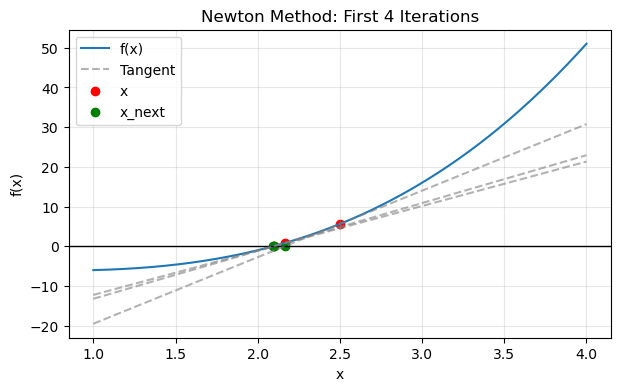

Newton Root: 2.094555232390448
Iterations: 3


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def newton_method(func, dfunc, x0, tol=1e-4, max_iter=100):
    x = x0
    rows = []

    for iteration in range(1, max_iter + 1):
        fx = func(x)
        dfx = dfunc(x)

        if dfx == 0:
            raise ZeroDivisionError("Newton method encountered zero derivative.")

        x_next = x - fx / dfx
        rows.append({
            "ITERATION NO.": iteration,
            "X": x,
            "F(X)": fx,
            "F'(X)": dfx,
            "X_NEXT": x_next,
            "ERROR": abs(x_next - x),
        })

        if abs(x_next - x) <= tol or abs(func(x_next)) <= tol:
            return x_next, iteration, pd.DataFrame(rows)

        x = x_next

    return x, max_iter, pd.DataFrame(rows)


root, iterations, table = newton_method(f, df, 2.5, tol=1e-4)
display(table)

xs = np.linspace(1.0, 4.0, 400)
ys = [f(x) for x in xs]
rows = table.head(4)

plt.figure(figsize=(7, 4))
plt.plot(xs, ys, label="f(x)")
plt.axhline(0, color="black", linewidth=1)
for i, row in rows.iterrows():
    x = row["X"]
    fx = row["F(X)"]
    dfx = row["F'(X)"]
    tangent = [fx + dfx * (xi - x) for xi in xs]
    label = "Tangent" if i == rows.index[0] else "_nolegend_"
    plt.plot(xs, tangent, "--", color="gray", alpha=0.6, label=label)
plt.scatter(rows["X"], [f(x) for x in rows["X"]], color="red", label="x")
plt.scatter(rows["X_NEXT"], [0 for _ in rows["X_NEXT"]], color="green", label="x_next")
plt.title("Newton Method: First 4 Iterations")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Newton Root:", root)
print("Iterations:", iterations)

Time Complexity: O(k)

Space Complexity: O(1)

### Method 5: Fixed Point Iteration Method

**Assumptions**

- g(x) is continuous on the interval.
- |g'(x)| < 1 near the root (convergence).
- Initial guess x0 is given.
- Tolerance e > 0 and max iterations N are given.

**Algorithm (Fixed Point Iteration Method)**

1. Start
2. Read function g(x), initial guess x0, tolerance e, max iterations N
3. Repeat for i = 1 to N
4.    x_next = g(x)
5.    If |x_next - x| <= e, print x_next as root
6.    Stop
7.    Set x = x_next
8. End Repeat
9. Print x as approximate root
10. Stop
11. End

,ITERATION NO.,X,X_NEXT,ERROR
0,1,2.500000,2.154435,0.345565
1,2,2.154435,2.103612,0.050823
2,3,2.103612,2.095927,0.007685
3,4,2.095927,2.094761,0.001167
4,5,2.094761,2.094583,0.000177
5,6,2.094583,2.094556,0.000027


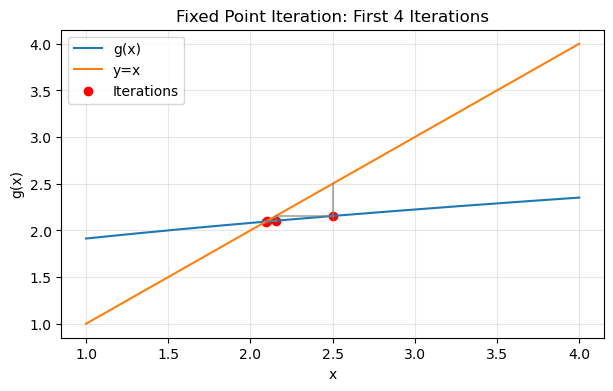

Fixed Point Root: 2.094556309071134
Iterations: 6


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def fixed_point_method(gfunc, x0, tol=1e-4, max_iter=100):
    x = x0
    rows = []

    for iteration in range(1, max_iter + 1):
        x_next = gfunc(x)
        rows.append({
            "ITERATION NO.": iteration,
            "X": x,
            "X_NEXT": x_next,
            "ERROR": abs(x_next - x),
        })

        if abs(x_next - x) <= tol:
            return x_next, iteration, pd.DataFrame(rows)

        x = x_next

    return x, max_iter, pd.DataFrame(rows)


root, iterations, table = fixed_point_method(g, 2.5, tol=1e-4)
display(table)

xs = np.linspace(1.0, 4.0, 400)
gx = [g(x) for x in xs]
rows = table.head(4)

plt.figure(figsize=(7, 4))
plt.plot(xs, gx, label="g(x)")
plt.plot(xs, xs, label="y=x")
for _, row in rows.iterrows():
    x = row["X"]
    x_next = row["X_NEXT"]
    plt.plot([x, x], [x, x_next], color="gray", alpha=0.6)
    plt.plot([x, x_next], [x_next, x_next], color="gray", alpha=0.6)
plt.scatter(rows["X"], rows["X_NEXT"], color="red", label="Iterations")
plt.title("Fixed Point Iteration: First 4 Iterations")
plt.xlabel("x")
plt.ylabel("g(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Fixed Point Root:", root)
print("Iterations:", iterations)

Time Complexity: O(k)

Space Complexity: O(1)